<a href="https://colab.research.google.com/github/klairebuilds-nano/BioSignals-Labwork/blob/main/Lab%203.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.5/79.5 kB 3.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 163.9/163.9 kB 11.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.9/10.9 MB 75.7 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-colab 1.0.0 requires pandas==2.2.2, but you have pandas 3.0.3 which is incompatible.
gradio 5.50.0 requires pandas<3.0,>=1.0, but you have pandas 3.0.3 which is incompatible.


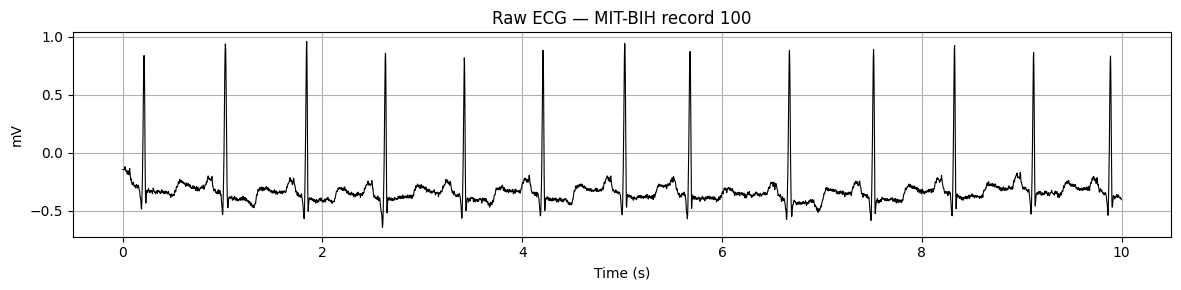

Samples: 3600 Duration: 10.0s Rate: 360Hz


In [1]:
!pip install wfdb -q
import wfdb, numpy as np, matplotlib.pyplot as plt
record = wfdb.rdrecord('100', pn_dir='mitdb', sampto=3600)
fs = record.fs # 360 samples per second
ecg = record.p_signal[:,0]
t = np.arange(len(ecg)) / fs
plt.figure(figsize=(12,3))
plt.plot(t, ecg, 'k', linewidth=0.8)
plt.title('Raw ECG — MIT-BIH record 100'); plt.xlabel('Time (s)'); plt.ylabel('mV')
plt.grid(True); plt.tight_layout(); plt.show()
print(f'Samples: {len(ecg)} Duration: {len(ecg)/fs:.1f}s Rate: {fs}Hz')

In [2]:
tiny = np.array([0.1, 0.3, -0.1, 0.4, -0.2, 0.2])
total = np.sum(tiny) # add all values
N = len(tiny) # how many values
mean = total / N # divide
print(f'Values : {tiny}')
print(f'Sum : {total:.2f}')
print(f'N : {N}')
print(f'Mean : {mean:.4f} mV')

Values : [ 0.1  0.3 -0.1  0.4 -0.2  0.2]
Sum : 0.70
N : 6
Mean : 0.1167 mV


ECG mean: -0.3199 mV


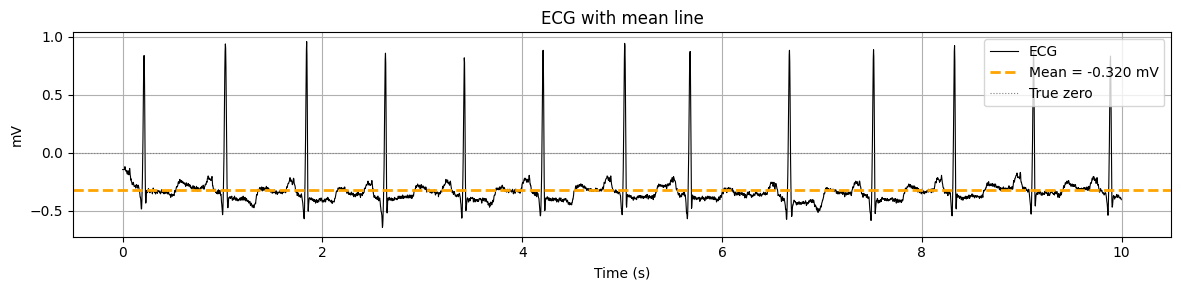

In [3]:
ecg_mean = np.mean(ecg)
print(f'ECG mean: {ecg_mean:.4f} mV')
plt.figure(figsize=(12,3))
plt.plot(t, ecg, 'k', linewidth=0.8, label='ECG')
plt.axhline(ecg_mean, color='orange', linewidth=2, linestyle='--', label=f'Mean = {ecg_mean:.3f} mV')
plt.axhline(0, color='gray', linewidth=0.8, linestyle=':', label='True zero')
plt.title('ECG with mean line'); plt.xlabel('Time (s)'); plt.ylabel('mV')
plt.legend(); plt.grid(True); plt.tight_layout(); plt.show()

Mean per window (mV): ['-0.279', '-0.320', '-0.344', '-0.335', '-0.321', '-0.318', '-0.355', '-0.335', '-0.301', '-0.291']


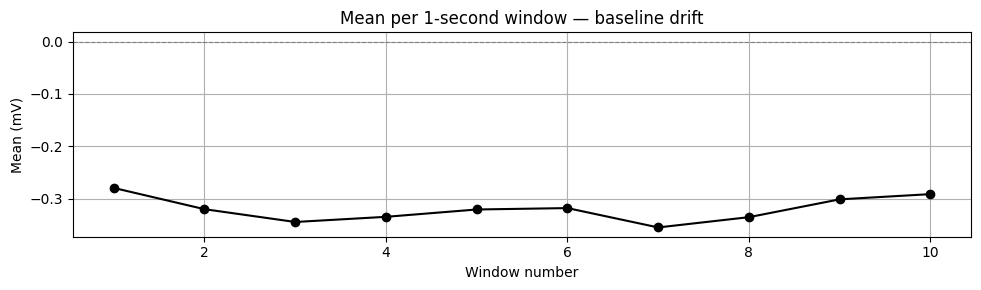

In [5]:
window_sec = 1.0
window_samples = int(window_sec * fs) # = 360
n_windows = len(ecg) // window_samples # = 10 windows
window_means = []
for i in range(n_windows):
  seg = ecg[i*window_samples : (i+1)*window_samples]
  window_means.append(np.mean(seg))

print('Mean per window (mV):', [f'{v:.3f}' for v in window_means])
plt.figure(figsize=(10,3))
plt.plot(range(1, n_windows+1), window_means, 'ko-', markersize=6)
plt.axhline(0, color='gray', linestyle='--', linewidth=0.8)
plt.title('Mean per 1-second window — baseline drift')
plt.xlabel('Window number'); plt.ylabel('Mean (mV)'); plt.grid(True)
plt.tight_layout(); plt.show()

In [6]:
clean = np.array([0.1, 0.2, 0.1, 0.3, 0.1, 0.2, 0.1])
with_spike = np.array([0.1, 0.2, 0.1, 0.3, 0.1, 0.2, 8.5]) # last value = artifact
print('=== Clean signal ===')
print(f'Values : {clean}')
print(f'Mean : {np.mean(clean):.3f} mV')
print(f'Median : {np.median(clean):.3f} mV')
print()
print('=== Same signal with one spike ===')
print(f'Values : {with_spike}')
print(f'Mean : {np.mean(with_spike):.3f} mV <-- dragged up by spike!')
print(f'Median : {np.median(with_spike):.3f} mV <-- unchanged')
# Show the sorted array so students see where median comes from
print()
print('Sorted:', sorted(with_spike))
print('Middle value (position 4 of 7):', sorted(with_spike)[3])

=== Clean signal ===
Values : [0.1 0.2 0.1 0.3 0.1 0.2 0.1]
Mean : 0.157 mV
Median : 0.100 mV

=== Same signal with one spike ===
Values : [0.1 0.2 0.1 0.3 0.1 0.2 8.5]
Mean : 1.357 mV <-- dragged up by spike!
Median : 0.200 mV <-- unchanged

Sorted: [np.float64(0.1), np.float64(0.1), np.float64(0.1), np.float64(0.2), np.float64(0.2), np.float64(0.3), np.float64(8.5)]
Middle value (position 4 of 7): 0.2


Mean = -0.3199 mV
Median = -0.3450 mV
Difference = 0.0251 mV


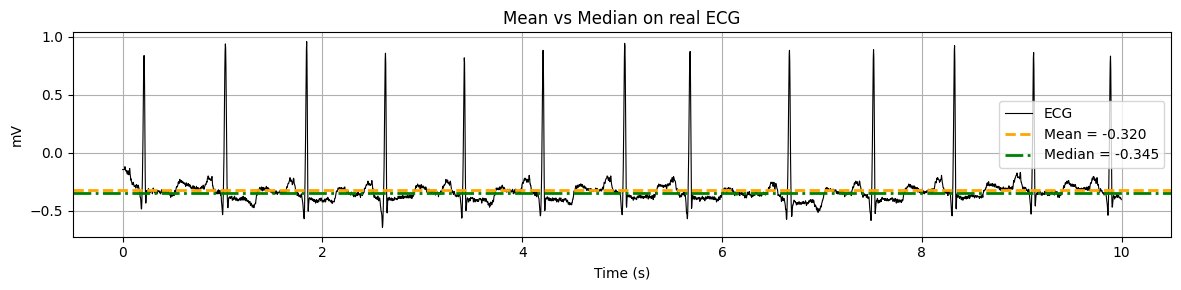

In [8]:
ecg_median = np.median(ecg)
print(f'Mean = {np.mean(ecg):.4f} mV')
print(f'Median = {ecg_median:.4f} mV')
print(f'Difference = {abs(np.mean(ecg)-ecg_median):.4f} mV')
# Show both lines on the ECG
plt.figure(figsize=(12,3))
plt.plot(t, ecg, 'k', linewidth=0.8, label='ECG')
plt.axhline(np.mean(ecg), color='orange', lw=2, ls='--', label=f'Mean = {np.mean(ecg):.3f}')
plt.axhline(ecg_median, color='green', lw=2, ls='-.', label=f'Median = {ecg_median:.3f}')
plt.title('Mean vs Median on real ECG')
plt.xlabel('Time (s)'); plt.ylabel('mV'); plt.legend(); plt.grid(True)
plt.tight_layout(); plt.show()

In [9]:
# A signal oscillating equally above and below zero
centered = np.array([0.5, -0.5, 0.5, -0.5, 0.5, -0.5])
mean_raw = np.mean(centered)
rms_val = np.sqrt(np.mean(centered**2))

print(f'Signal : {centered}')
print(f'Mean: {mean_raw:.2f} mV <-- says zero energy (wrong!)')
print(f'RMS: {rms_val:.4f} mV <-- captures true size')

# Show what squaring does to the values
print(f'Squared: {centered**2}')
print('All positive — energy is real even though mean = 0')

Signal : [ 0.5 -0.5  0.5 -0.5  0.5 -0.5]
Mean: 0.00 mV <-- says zero energy (wrong!)
RMS: 0.5000 mV <-- captures true size
Squared: [0.25 0.25 0.25 0.25 0.25 0.25]
All positive — energy is real even though mean = 0


RMS per window: ['0.3134', '0.3900', '0.3749', '0.3618', '0.3539', '0.3822', '0.3897', '0.3674', '0.3360', '0.3470']


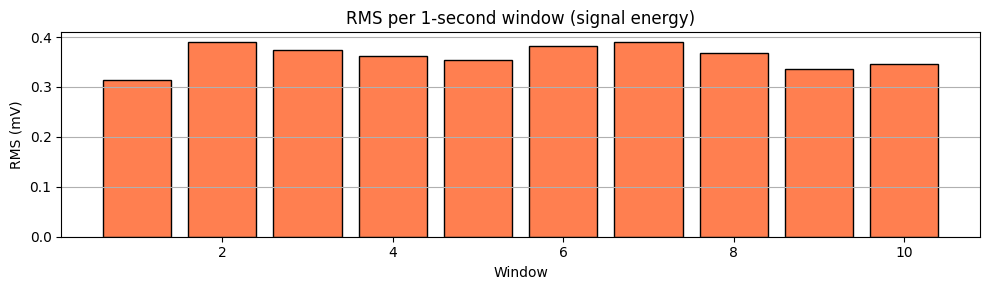

In [11]:
win_rms = []
for i in range(n_windows):
  seg = ecg[i*window_samples : (i+1)*window_samples]
  win_rms.append(np.sqrt(np.mean(seg**2)))

print('RMS per window:', [f'{v:.4f}' for v in win_rms])
plt.figure(figsize=(10,3))
plt.bar(range(1,n_windows+1), win_rms, color='coral', edgecolor='k')
plt.title('RMS per 1-second window (signal energy)')
plt.xlabel('Window'); plt.ylabel('RMS (mV)'); plt.grid(True, axis='y')
plt.tight_layout(); plt.show()

Maximum value : 0.960 mV
Minimum value : -0.645 mV
Peak-to-peak : 1.605 mV


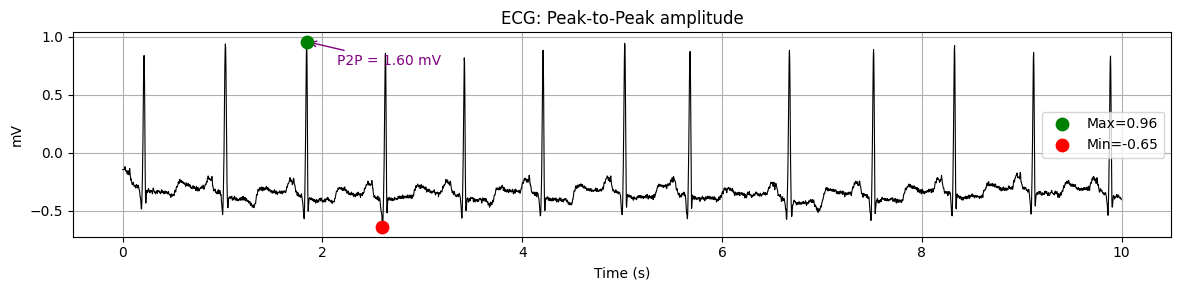

In [12]:
ecg_max = np.max(ecg)
ecg_min = np.min(ecg)
p2p= ecg_max - ecg_min

print(f'Maximum value : {ecg_max:.3f} mV')
print(f'Minimum value : {ecg_min:.3f} mV')
print(f'Peak-to-peak : {p2p:.3f} mV')

# Mark max and min on the ECG
max_idx = np.argmax(ecg)
min_idx = np.argmin(ecg)

plt.figure(figsize=(12,3))
plt.plot(t, ecg, 'k', linewidth=0.8)
plt.scatter(t[max_idx], ecg[max_idx], color='green', zorder=5, s=80,
label=f'Max={ecg_max:.2f}')
plt.scatter(t[min_idx], ecg[min_idx], color='red',
zorder=5, s=80,
label=f'Min={ecg_min:.2f}')
plt.annotate(f'P2P = {p2p:.2f} mV', xy=(t[max_idx], ecg[max_idx]),
  xytext=(t[max_idx]+0.3, ecg[max_idx]-0.2), fontsize=10,
  arrowprops=dict(arrowstyle='->', color='purple'), color='purple')
plt.title('ECG: Peak-to-Peak amplitude')
plt.xlabel('Time (s)'); plt.ylabel('mV'); plt.legend(); plt.grid(True)
plt.tight_layout(); plt.show()

In [13]:
features = {
'Mean (mV)': np.mean(ecg),
'Median (mV)': np.median(ecg),
'Variance (mV2)': np.var(ecg),
'Std Dev (mV)': np.std(ecg),
'RMS (mV)': np.sqrt(np.mean(ecg**2)),
'Peak-to-Peak (mV)': np.max(ecg) - np.min(ecg),
}

print('='*42)
print(f' BME 366 — ECG Feature Summary')
print('='*42)
for name, val in features.items():
  print(f' {name:<22}: {val:+.4f}')

print('='*42)

 BME 366 — ECG Feature Summary
 Mean (mV)             : -0.3199
 Median (mV)           : -0.3450
 Variance (mV2)        : +0.0290
 Std Dev (mV)          : +0.1702
 RMS (mV)              : +0.3624
 Peak-to-Peak (mV)     : +1.6050


Windows created : 10
Hop size: 360 samples (1.00s)
Overlap: 0%


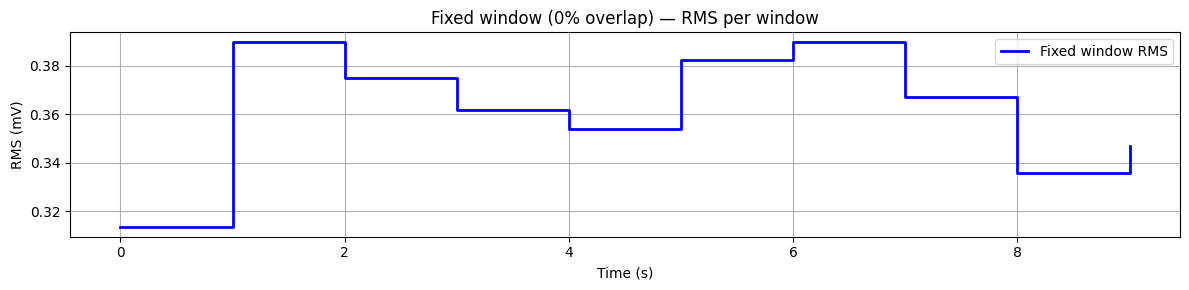

In [14]:
window_sec = 1.0
W = int(window_sec * fs) # 360 samples = 1 second
hop = W # 100% hop = no overlap

t_win, rms_win = [], []
i = 0

while i + W <= len(ecg):
  seg = ecg[i : i+W]
  rms_win.append(np.sqrt(np.mean(seg**2)))
  t_win.append(i / fs) # time of window start
  i += hop # move forward by full window

print(f'Windows created : {len(rms_win)}')
print(f'Hop size: {hop} samples ({hop/fs:.2f}s)')
print(f'Overlap: 0%')

plt.figure(figsize=(12,3))
plt.step(t_win, rms_win, 'b', where='post', linewidth=2, label='Fixed window RMS')
plt.title('Fixed window (0% overlap) — RMS per window')
plt.xlabel('Time (s)'); plt.ylabel('RMS (mV)'); plt.legend(); plt.grid(True)
plt.tight_layout(); plt.show()

Sliding windows : 19
Hop size: 180 samples (0.50s)
Overlap: 50%


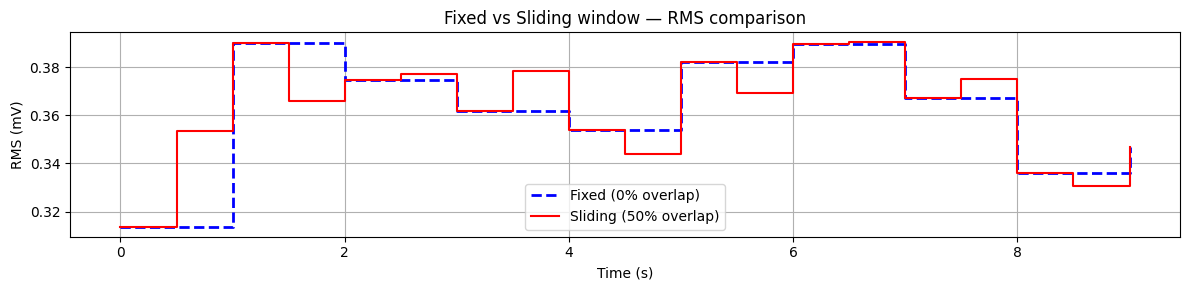

In [18]:
hop_slide = W // 2 # 50% hop = 180 samples = 0.5 seconds

t_slide, rms_slide = [], []
i = 0

while i + W <= len(ecg):
  seg = ecg[i : i+W]
  rms_slide.append(np.sqrt(np.mean(seg**2)))
  t_slide.append(i / fs)
  i += hop_slide # move forward by HALF window

print(f'Sliding windows : {len(rms_slide)}')
print(f'Hop size: {hop_slide} samples ({hop_slide/fs:.2f}s)')
print(f'Overlap: 50%')

# Compare both on the same plot
plt.figure(figsize=(12,3))
plt.step(t_win,rms_win,'b--', where='post', linewidth=2, label='Fixed (0% overlap)')
plt.step(t_slide, rms_slide, 'r',where='post', linewidth=1.5, label='Sliding (50% overlap)')
plt.title('Fixed vs Sliding window — RMS comparison')
plt.xlabel('Time (s)'); plt.ylabel('RMS (mV)'); plt.legend(); plt.grid(True)
plt.tight_layout(); plt.show()

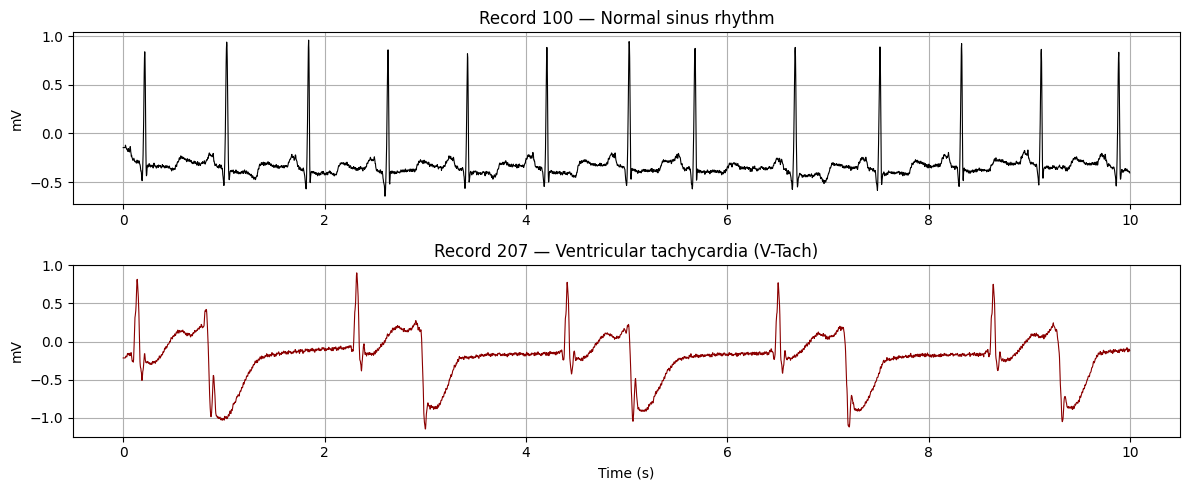

In [19]:
# Load normal record
rec_normal = wfdb.rdrecord('100', pn_dir='mitdb', sampto=3600)
ecg_normal = rec_normal.p_signal[:,0]
fs_n = rec_normal.fs
t_n = np.arange(len(ecg_normal)) / fs_n

# Load ventricular tachycardia record
rec_vtach = wfdb.rdrecord('207', pn_dir='mitdb', sampto=3600)
ecg_vtach = rec_vtach.p_signal[:,0]
fs_v = rec_vtach.fs
t_v = np.arange(len(ecg_vtach)) / fs_v

fig, axes = plt.subplots(2, 1, figsize=(12, 5))
axes[0].plot(t_n, ecg_normal, 'k', linewidth=0.8)
axes[0].set_title('Record 100 — Normal sinus rhythm', fontsize=12)
axes[0].set_ylabel('mV'); axes[0].grid(True)

axes[1].plot(t_v, ecg_vtach, 'darkred', linewidth=0.8)
axes[1].set_title('Record 207 — Ventricular tachycardia (V-Tach)', fontsize=12)
axes[1].set_ylabel('mV'); axes[1].set_xlabel('Time (s)'); axes[1].grid(True)

plt.tight_layout(); plt.show()

In [20]:
def compute_features(ecg):
  return {
      'Mean (mV)': np.mean(ecg),
      'Median (mV)': np.median(ecg),
      'Std Dev (mV)': np.std(ecg),
      'RMS (mV)': np.sqrt(np.mean(ecg**2)),
      'Peak-to-Peak (mV)': np.max(ecg) - np.min(ecg),
      'Variance (mV2)': np.var(ecg),
  }

feat_n = compute_features(ecg_normal)
feat_v = compute_features(ecg_vtach)

print(f'{'Feature':<22} {'Normal':>12} {'V-Tach':>12} Change')
print('-' * 55)
for key in feat_n:
    n, v = feat_n[key], feat_v[key]
    direction = 'HIGHER' if v > n else 'lower'
    print(f'{key:<22} {n:>12.4f} {v:>12.4f} {direction}')

Feature                      Normal       V-Tach Change
-------------------------------------------------------
Mean (mV)                   -0.3199      -0.2081 HIGHER
Median (mV)                 -0.3450      -0.1700 HIGHER
Std Dev (mV)                 0.1702       0.3030 HIGHER
RMS (mV)                     0.3624       0.3676 HIGHER
Peak-to-Peak (mV)            1.6050       2.0450 HIGHER
Variance (mV2)               0.0290       0.0918 HIGHER


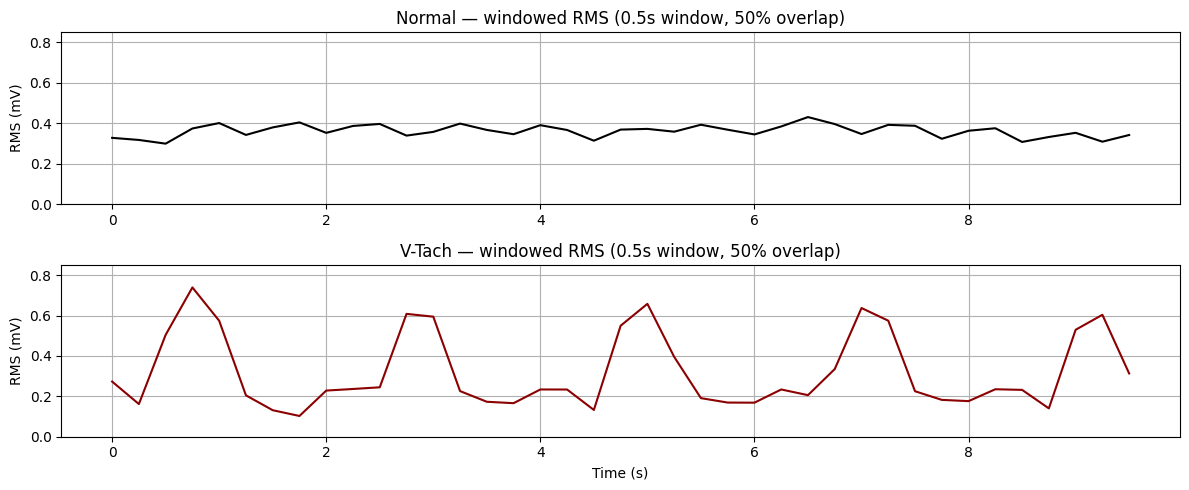

Normal — mean RMS: 0.3613 mV, std of RMS: 0.0308
V-Tach — mean RMS: 0.3211 mV, std of RMS: 0.1841


In [23]:
window_samples = int(0.5 * fs_n) # 0.5-second windows
hop = window_samples // 2 # 50% overlap

def windowed_rms(ecg, win, hop):
    rms_vals, t_vals = [], []
    i = 0
    while i + win <= len(ecg):
        seg = ecg[i:i+win]
        rms_vals.append(np.sqrt(np.mean(seg**2)))
        t_vals.append(i / fs_n)
        i += hop
    return np.array(t_vals), np.array(rms_vals)
t_rms_n, rms_n = windowed_rms(ecg_normal, window_samples, hop)
t_rms_v, rms_v = windowed_rms(ecg_vtach,window_samples, hop)

fig, axes = plt.subplots(2, 1, figsize=(12, 5))
axes[0].plot(t_rms_n, rms_n, 'k', linewidth=1.5)
axes[0].set_title('Normal — windowed RMS (0.5s window, 50% overlap)')
axes[0].set_ylabel('RMS (mV)'); axes[0].grid(True)
axes[0].set_ylim(0, max(rms_n.max(), rms_v.max())*1.15)

axes[1].plot(t_rms_v, rms_v, 'darkred', linewidth=1.5)
axes[1].set_title('V-Tach — windowed RMS (0.5s window, 50% overlap)')
axes[1].set_ylabel('RMS (mV)'); axes[1].set_xlabel('Time (s)'); axes[1].grid(True)
axes[1].set_ylim(0, max(rms_n.max(), rms_v.max())*1.15)

plt.tight_layout(); plt.show()

print(f'Normal — mean RMS: {rms_n.mean():.4f} mV, std of RMS: {rms_n.std():.4f}')
print(f'V-Tach — mean RMS: {rms_v.mean():.4f} mV, std of RMS: {rms_v.std():.4f}')




Normal : 13 beats in 10s -> 78 bpm
V-Tach : 5 beats in 10s -> 30 bpm

Clinical note: heart rate above 150 bpm with wide QRS = V-Tach until proven otherwise


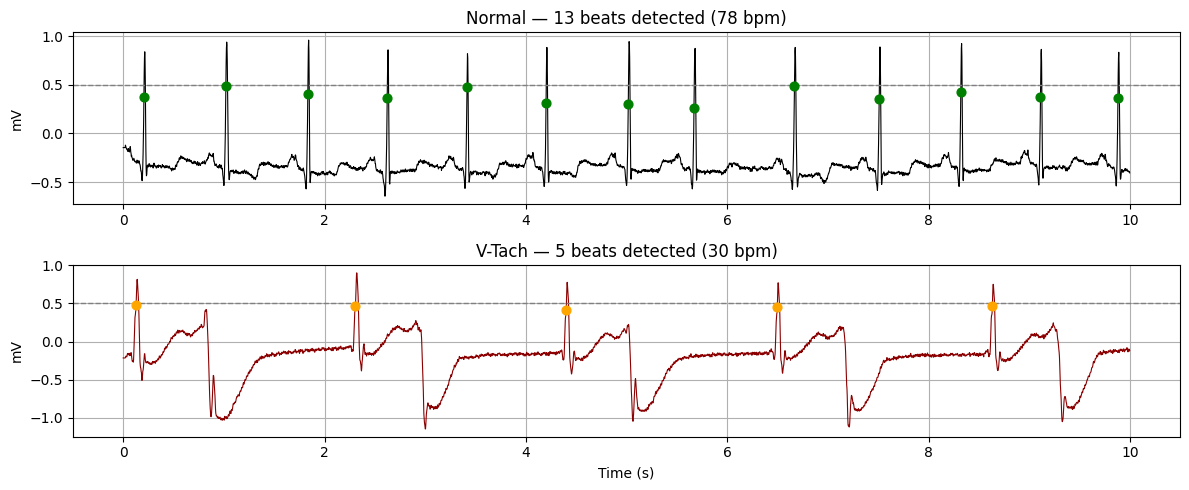

In [25]:
threshold = 0.5 # mV
def detect_beats(ecg, thresh):
    above = ecg > thresh
    crossings = np.where(np.diff(above.astype(int)) == 1)[0]
    return crossings

beats_n = detect_beats(ecg_normal, threshold)
beats_v = detect_beats(ecg_vtach, threshold)

hr_n = len(beats_n) / (len(ecg_normal)/fs_n) * 60
hr_v = len(beats_v) / (len(ecg_vtach) /fs_v) * 60

print(f'Normal : {len(beats_n)} beats in 10s -> {hr_n:.0f} bpm')
print(f'V-Tach : {len(beats_v)} beats in 10s -> {hr_v:.0f} bpm')
print()
print('Clinical note: heart rate above 150 bpm with wide QRS = V-Tach until proven otherwise')

fig, axes = plt.subplots(2,1,figsize=(12,5))
axes[0].plot(t_n, ecg_normal, 'k', lw=0.8)
axes[0].scatter(beats_n/fs_n, ecg_normal[beats_n], color='green', s=40, zorder=5)
axes[0].axhline(threshold, color='gray', ls='--', lw=1)
axes[0].set_title(f'Normal — {len(beats_n)} beats detected ({hr_n:.0f} bpm)')
axes[0].set_ylabel('mV'); axes[0].grid(True)

axes[1].plot(t_v, ecg_vtach, 'darkred', lw=0.8)
axes[1].scatter(beats_v/fs_v, ecg_vtach[beats_v], color='orange', s=40, zorder=5)
axes[1].axhline(threshold, color='gray', ls='--', lw=1)
axes[1].set_title(f'V-Tach — {len(beats_v)} beats detected ({hr_v:.0f} bpm)')
axes[1].set_ylabel('mV'); axes[1].set_xlabel('Time (s)'); axes[1].grid(True)

plt.tight_layout(); plt.show()